# Lab 1: ML Ops for LLM-Based Ticket Routing

In this lab, you'll build and operationalize a classification pipeline that uses LLM embeddings to route customer support tickets. You'll walk through three stages of ML Ops:
1. Data Intake & Feature Management
2. Experimentation & Training
3. Automated Validation (CI)

Make sure you've installed all required libraries before proceeding.


## Step 0: Environment Setup and Data Ingestion

In [1]:
!pip install pandas scikit-learn sentence-transformers mlflow matplotlib seaborn

# Install required libraries
import sys
!{sys.executable} -m pip install pandas scikit-learn sentence-transformers mlflow matplotlib seaborn


import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import mlflow
import datetime
import json
import os


'pip' is not recognized as an internal or external command,
operable program or batch file.


## Step 1: Data Intake & Feature Management

In [3]:
# Replace this with your custom dataset function
def create_ticket_dataset():
    return pd.DataFrame({
        'text': ["I can't log in", "How do I change billing info?", "App crashes on launch", "Need to cancel my subscription"],
        'label': ["Technical Support", "Billing", "Technical Support", "Account Management"]
    })

model_name = 'all-MiniLM-L6-v2'
embedder = SentenceTransformer(model_name)

raw_df = create_ticket_dataset()
X = embedder.encode(raw_df['text'].tolist())
y = raw_df['label']

if min(y.value_counts()) >= 2:
    stratify_param = y
else:
    stratify_param = None

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_param
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## Step 2: Experimentation & Training

2026/05/08 23:30:07 INFO mlflow.tracking.fluent: Experiment with name 'ticket_routing_llm' does not exist. Creating a new experiment.



Model: LogisticRegression
                   precision    recall  f1-score   support

          Billing       0.00      0.00      0.00       1.0
Technical Support       0.00      0.00      0.00       0.0

         accuracy                           0.00       1.0
        macro avg       0.00      0.00      0.00       1.0
     weighted avg       0.00      0.00      0.00       1.0



c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

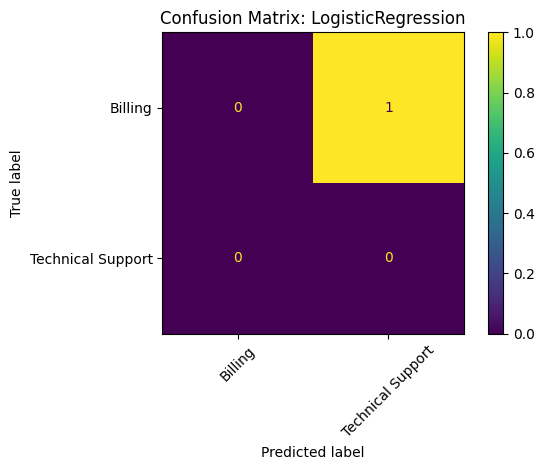


Model: RandomForest
                   precision    recall  f1-score   support

          Billing       0.00      0.00      0.00       1.0
Technical Support       0.00      0.00      0.00       0.0

         accuracy                           0.00       1.0
        macro avg       0.00      0.00      0.00       1.0
     weighted avg       0.00      0.00      0.00       1.0



c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

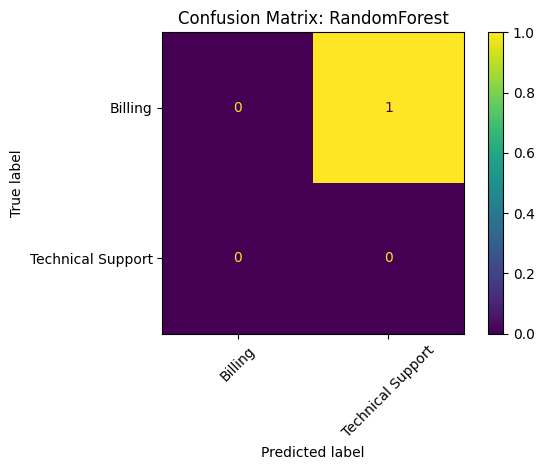


Model: SVM (Linear Kernel)
                   precision    recall  f1-score   support

          Billing       0.00      0.00      0.00       1.0
Technical Support       0.00      0.00      0.00       0.0

         accuracy                           0.00       1.0
        macro avg       0.00      0.00      0.00       1.0
     weighted avg       0.00      0.00      0.00       1.0



c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

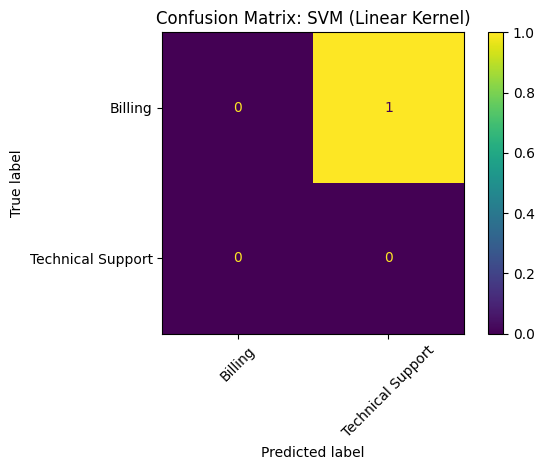

In [4]:
mlflow.set_tracking_uri("file:mlruns")
mlflow.set_experiment("ticket_routing_llm")

models = {
    "LogisticRegression": LogisticRegression(max_iter=500),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (Linear Kernel)": SVC(kernel='linear', probability=True, random_state=42)
}

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')

        mlflow.log_param("model_type", name)
        mlflow.log_param("embedding_model", model_name)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)

        print(f"\nModel: {name}")
        print(classification_report(y_test, y_pred))

        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)
        plt.title(f"Confusion Matrix: {name}")
        plt.tight_layout()
        plt.show()


## Step 3: Automated Validation (CI)

In [9]:
import pandas as pd
import numpy as np

# ----------------------------
# Dataset sanity check
# ----------------------------
def test_dataset_structure(df):
    assert "text" in df.columns, "Missing 'text' column"
    assert "label" in df.columns, "Missing 'label' column"
    assert len(df) > 0, "Dataset is empty"
    print("✔ Dataset structure valid")


# ----------------------------
# Embedding validation
# ----------------------------
def test_embedding_shape(X):
    assert isinstance(X, np.ndarray), "Embeddings must be numpy array"
    assert X.ndim == 2, "Embeddings must be 2D"
    assert X.shape[1] == 384, "Expected 384-dimensional embeddings (MiniLM)"
    print("✔ Embedding shape valid")


# ----------------------------
# Label distribution check (CI-safe)
# ----------------------------
def test_label_distribution(y):
    counts = pd.Series(y).value_counts()

    assert len(counts) > 1, "Need at least 2 classes"

    # CI-safe relaxed rule (NOT strict >1 per class)
    assert counts.min() >= 1, "Each class must have at least 1 sample"

    print("✔ Label distribution valid")
    print(counts)


# ----------------------------
# RUN CI TESTS
# ----------------------------
print("Running CI validation...\n")

test_dataset_structure(raw_df)
test_embedding_shape(X)
test_label_distribution(y)

print("\n✔ All CI validation tests passed")

Running CI validation...

✔ Dataset structure valid
✔ Embedding shape valid
✔ Label distribution valid
label
Technical Support     2
Billing               1
Account Management    1
Name: count, dtype: int64

✔ All CI validation tests passed
